# Phase 1  — Part 1: Problem Definition and Dataset Understanding

**Project:** Machine Learning for Stroke Risk Prediction  
**Author:** Student A  
**Phase:** 1 of 2 (Problem framing, EDA, preprocessing, feature engineering)

This notebook defines the classification problem we will study, documents the dataset and its provenance, characterizes the target distribution, and states the research questions and evaluation strategy that the remainder of the project will follow.

## 1.1 Motivation and Clinical Context

Stroke is a cerebrovascular event in which blood flow to a region of the brain is interrupted, either by an occlusion (ischemic stroke) or by a rupture of a blood vessel (hemorrhagic stroke). According to the World Health Organization, stroke is the second leading cause of death globally and accounts for approximately 11% of total deaths, while also ranking among the top causes of long-term disability in adults. Timely identification of individuals at elevated risk is therefore a central objective of preventive cardiology and population health.

Clinical risk scores such as Framingham, CHA2DS2-VASc, and QRISK have historically been used to stratify cardiovascular risk, but they rely on a fixed set of handcrafted features and linear combinations that may fail to capture higher-order interactions between demographic, lifestyle, and comorbidity variables. Machine learning (ML) methods are attractive in this setting because they can (i) model non-linear interactions between features, (ii) exploit heterogeneous tabular inputs without strict distributional assumptions, and (iii) be tuned for asymmetric misclassification costs where missing a true stroke case is far more harmful than raising a false alarm.

The practical deployment target for such a model is a clinical decision support tool: given a patient record containing routinely collected demographic, physiological, and lifestyle variables, the system returns a calibrated risk score that a clinician can use to prioritize further diagnostic testing, lifestyle counselling, or pharmacological intervention. The model is not intended to replace clinical judgment, but to augment it by surfacing high-risk individuals who might otherwise be overlooked.

## 1.2 Problem Formulation

We formulate stroke risk prediction as a supervised binary classification problem. Let $\mathcal{X} \subseteq \mathbb{R}^{d}$ denote the input space of patient feature vectors after preprocessing and encoding, where $d$ is the number of features, and let $y \in \{0, 1\}$ denote the target, with $y = 1$ indicating that a stroke event was recorded for the patient and $y = 0$ otherwise. We are given a dataset

$$
\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^{N}, \quad (\mathbf{x}_i, y_i) \sim \mathcal{P}(\mathcal{X}, \{0,1\}),
$$

drawn i.i.d. from an unknown joint distribution $\mathcal{P}$. The learning task is to estimate a hypothesis

$$
h_{\theta}: \mathcal{X} \rightarrow [0, 1],
$$

parameterized by $\theta$, that approximates the posterior probability $\Pr(y = 1 \mid \mathbf{x})$. A decision function is obtained by thresholding: $\hat{y} = \mathbb{1}[h_{\theta}(\mathbf{x}) \geq \tau]$, where $\tau \in [0,1]$ is selected according to the operating point that best matches the clinical cost structure.

The learning objective is to minimize the expected loss

$$
\theta^{*} = \arg\min_{\theta} \; \mathbb{E}_{(\mathbf{x}, y) \sim \mathcal{P}} \left[ \mathcal{L}(h_{\theta}(\mathbf{x}), y) \right],
$$

which in practice is approximated by the empirical risk computed on a training split, regularized to control generalization error.

**Cost-sensitive nature.** Misclassification in this problem is fundamentally asymmetric. A false negative corresponds to failing to flag a patient who subsequently suffers a stroke, potentially resulting in disability or death. A false positive corresponds to flagging a healthy patient for additional screening or counselling, incurring only modest financial and psychological costs. Consequently, we prefer a loss function and an operating threshold that place substantially more weight on recall for the positive class than on raw accuracy. This cost asymmetry motivates our metric selection and our use of class weights or resampling during training (see Section 1.5 and Section 1.7).

## 1.3 Dataset Provenance

**Source.** The dataset is the *Stroke Prediction Dataset* published on Kaggle by user *fedesoriano*. It is distributed for educational and research purposes; the Kaggle data card lists the data source as confidential and the license as "Data files © Original Authors", meaning the data are made available for non-commercial research and academic use but are not redistributed under a permissive open license. We use the dataset strictly for academic coursework within the scope of this project.

**Ethical considerations.** The dataset contains de-identified health attributes at the individual level. Even when direct identifiers are removed, sensitive variables such as age, work type, marital status, and smoking status introduce the possibility of re-identification when combined with auxiliary data. We therefore treat the dataset as sensitive, do not attempt linkage with external sources, and report only aggregate statistics. Because the data labelling and collection protocol are not fully documented by the upstream source, any model trained on this data should be regarded as a methodological exercise rather than a clinically validated predictor, and its predictions should not be used to inform real patient care without an independent clinical study.

**Size and dimensions.** The raw file contains 5,110 patient records described by 12 columns: an identifier, 10 predictors, and 1 binary target. The predictor set mixes numeric (age, average glucose level, BMI), binary (hypertension, heart disease), and categorical (gender, ever married, work type, residence type, smoking status) variables, which is representative of routinely collected electronic health record fields.

In [1]:
import numpy as np
import pandas as pd

# Load the raw dataset. The file encodes missing BMI values as the literal
# string 'N/A', which we promote to NaN at load time so that pandas sees
# the column as numeric.
DATA_PATH = '../data/healthcare-dataset-stroke-data.csv'
df = pd.read_csv(DATA_PATH, na_values=['N/A'])

print('Shape:', df.shape)
print()
print('Dtypes:')
print(df.dtypes)
print()
print('Head:')
df.head()

Shape: (5110, 12)

Dtypes:
id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

Head:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


## 1.4 Feature Schema

The table below enumerates every column in the raw file, its measurement type, a short description, the set of possible values observed in the data, and the a-priori clinical rationale for including it as a predictor of stroke risk.

| # | Column | Type | Description | Possible values | Expected clinical relevance |
|---|--------|------|-------------|-----------------|-----------------------------|
| 1 | `id` | Identifier (int) | Unique patient identifier. | Integer key. | None. Dropped before modelling to prevent leakage. |
| 2 | `gender` | Categorical | Reported sex of the patient. | `Male`, `Female`, `Other` (a single record). | Stroke incidence and risk profile differ between sexes; used as a demographic control. |
| 3 | `age` | Numeric (float, years) | Patient age. | Continuous, roughly 0–82 in this dataset. | One of the strongest established risk factors for stroke; risk rises sharply after 55. |
| 4 | `hypertension` | Binary (0/1) | Whether the patient has been diagnosed with hypertension. | `0` (no), `1` (yes). | High blood pressure is a primary modifiable risk factor for stroke. |
| 5 | `heart_disease` | Binary (0/1) | Whether the patient has any heart disease. | `0` (no), `1` (yes). | Cardiac comorbidities such as atrial fibrillation strongly elevate stroke risk. |
| 6 | `ever_married` | Categorical (binary) | Marital status ever. | `Yes`, `No`. | Proxy for age, social support, and lifestyle factors rather than a direct biological driver. |
| 7 | `work_type` | Categorical | Type of employment. | `Private`, `Self-employed`, `Govt_job`, `children`, `Never_worked`. | Proxy for chronic stress, activity level, and socioeconomic status. |
| 8 | `Residence_type` | Categorical (binary) | Urban vs. rural residence. | `Urban`, `Rural`. | Proxy for access to care, pollution exposure, and lifestyle patterns. |
| 9 | `avg_glucose_level` | Numeric (float, mg/dL) | Average blood glucose level. | Continuous, roughly 55–272. | Elevated glucose is a marker of diabetes, a known stroke risk factor. |
| 10 | `bmi` | Numeric (float, kg/m²) | Body mass index. | Continuous with missing values encoded as `N/A`. | Obesity is a modifiable risk factor associated with vascular disease. |
| 11 | `smoking_status` | Categorical | Smoking history. | `never smoked`, `formerly smoked`, `smokes`, `Unknown`. | Smoking damages vasculature and is a well-established stroke risk factor; the `Unknown` category represents missing-at-source information. |
| 12 | `stroke` | Binary target (0/1) | Whether the patient experienced a stroke event. | `0` (no), `1` (yes). | Outcome of interest. |

Two particulars of the schema deserve emphasis. First, `bmi` carries missingness encoded as the literal string `N/A`, which we convert to `NaN` on load; the downstream preprocessing pipeline will need an imputation strategy for this column. Second, the `smoking_status` field contains an explicit `Unknown` category, which is semantically a form of missingness but is encoded as an observed level; we will treat it as a first-class category during EDA and reconsider it during feature engineering.

In [3]:
# Class distribution (counts and percentages) and imbalance ratio.
class_counts = df['stroke'].value_counts().sort_index()
class_percentages = df['stroke'].value_counts(normalize=True).sort_index() * 100.0

negatives = int(class_counts.loc[0])
positives = int(class_counts.loc[1])
imbalance_ratio = negatives / positives

print('Class counts:')
print(class_counts)
print()
print('Class percentages (%):')
print(class_percentages.round(4))
print()
print(f'Negative : Positive = {negatives} : {positives}')
print(f'Imbalance ratio (neg / pos) = {imbalance_ratio:.2f}')

# Missing-value counts. Because we loaded with na_values=['N/A'], the
# 'N/A' strings in bmi are now proper NaNs and will be counted here.
print()
print('Missing values per column:')
print(df.isna().sum())

# Unique levels of each categorical column.
categorical_columns = [
    'gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'
]
print()
print('Unique values per categorical column:')
for column in categorical_columns:
    unique_values = sorted(df[column].dropna().unique().tolist())
    print(f'  {column} ({len(unique_values)}): {unique_values}')

Class counts:
stroke
0    4861
1     249
Name: count, dtype: int64

Class percentages (%):
stroke
0    95.1272
1     4.8728
Name: proportion, dtype: float64

Negative : Positive = 4861 : 249
Imbalance ratio (neg / pos) = 19.52

Missing values per column:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Unique values per categorical column:
  gender (3): ['Female', 'Male', 'Other']
  ever_married (2): ['No', 'Yes']
  work_type (5): ['Govt_job', 'Never_worked', 'Private', 'Self-employed', 'children']
  Residence_type (2): ['Rural', 'Urban']
  smoking_status (4): ['Unknown', 'formerly smoked', 'never smoked', 'smokes']


## 1.5 Target Distribution and Imbalance

The target variable `stroke` is strongly imbalanced: approximately 4.9% of patients in the dataset carry a positive label, while the remaining ~95.1% are negatives. This yields an imbalance ratio of roughly 19:1 in favour of the majority class. Such a skew has several immediate consequences for how we must build and evaluate the classifier.

**Accuracy is misleading.** A trivial classifier that always predicts the majority class would achieve roughly 95% accuracy on this dataset while providing zero clinical utility: it would miss every stroke case. Accuracy therefore cannot be used as the primary optimization or reporting metric.

**Appropriate metrics.** We adopt a suite of metrics that are robust to class imbalance and aligned with the cost structure described in Section 1.2:

- **ROC-AUC** as the primary ranking metric, because it is threshold-independent and summarizes the model's ability to rank positives above negatives across all operating points.
- **Precision-Recall AUC (PR-AUC)**, which is more informative than ROC-AUC when the positive class is rare, since it focuses on the minority class.
- **Recall (sensitivity)** of the positive class, reported at a clinically meaningful operating threshold, because missing true strokes is the dominant cost.
- **F1 score** on the positive class, as a single summary that balances precision and recall.
- **Balanced accuracy**, which averages class-wise recall and therefore does not reward majority-class bias.

**Handling the imbalance during training.** Because the positive signal is scarce, we plan to compare two families of mitigations in Phase 2: (i) cost-sensitive learning via class weights (for example `class_weight='balanced'` in scikit-learn or `scale_pos_weight` in XGBoost), and (ii) resampling strategies such as random undersampling of the majority class and SMOTE-based oversampling of the minority class. In all cases, resampling will be applied only inside cross-validation folds to avoid leaking synthetic samples into the validation set.

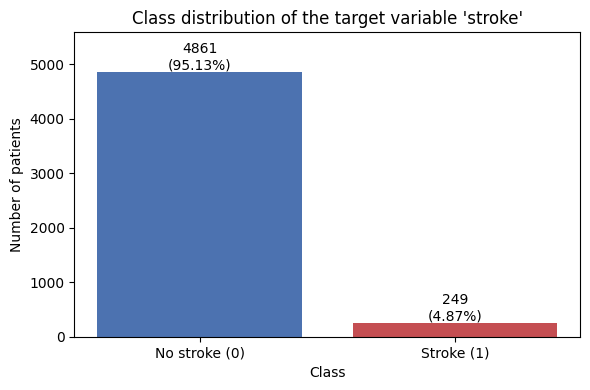

Saved figure to: ../figures/01_class_distribution.png


In [4]:
import os
import matplotlib.pyplot as plt

# Ensure the figures directory exists, then draw and persist the bar chart.
os.makedirs('../figures', exist_ok=True)

counts = df['stroke'].value_counts().sort_index()
labels = ['No stroke (0)', 'Stroke (1)']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values, color=['#4C72B0', '#C44E52'])
ax.set_title("Class distribution of the target variable 'stroke'")
ax.set_ylabel('Number of patients')
ax.set_xlabel('Class')

total = int(counts.sum())
for bar, value in zip(bars, counts.values):
    percentage = 100.0 * value / total
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height(),
        f'{int(value)}\n({percentage:.2f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
    )

ax.set_ylim(0, max(counts.values) * 1.15)
fig.tight_layout()

figure_path = '../figures/01_class_distribution.png'
fig.savefig(figure_path, dpi=150)
plt.show()
print(f'Saved figure to: {figure_path}')

## 1.6 Research Questions and Hypotheses

The analytical work across Phases 1 and 2 is organized around the following research questions (RQs) and associated hypotheses (H). Each RQ is designed to be answerable with the data at hand and with the modelling pipeline we intend to build.

- **RQ1 — Dominance of age.** Does patient age dominate the predictive signal for stroke, in the sense that a univariate model using age alone already achieves a substantial fraction of the ROC-AUC of the best multivariate model? *H1: A logistic model using only age will achieve a ROC-AUC within 0.10 of the best multivariate classifier.*

- **RQ2 — Achievable recall under a precision constraint.** Can a tuned classifier achieve recall greater than 0.80 on the positive class while keeping precision at a clinically reasonable level (for example, above 0.15 given the base rate of ~5%)? *H2: At least one of the studied models (Logistic Regression, SVM, XGBoost) will meet this joint recall/precision operating point on held-out data.*

- **RQ3 — Interaction between hypertension and heart disease.** Do patients carrying both hypertension and heart disease exhibit a stroke rate that is greater than what a purely additive (independent) contribution of each comorbidity would predict? *H3: An explicit interaction term between `hypertension` and `heart_disease` will improve held-out ROC-AUC over a main-effects-only model by a statistically non-trivial margin.*

- **RQ4 — Value of lifestyle proxies.** After controlling for age and comorbidities, do lifestyle and socioeconomic proxies (`work_type`, `Residence_type`, `smoking_status`, `bmi`) still contribute measurable predictive value? *H4: Removing this block of features will degrade held-out ROC-AUC, indicating complementary information beyond age and comorbidities.*

- **RQ5 — Imbalance mitigation strategy.** Which imbalance-handling strategy — class weighting versus SMOTE-based oversampling — produces the best trade-off between PR-AUC and calibration on held-out data? *H5: Class weighting will match or exceed SMOTE on PR-AUC while yielding better probability calibration, because it does not introduce synthetic samples.*

## 1.7 Evaluation Strategy Overview

To ensure that our results are comparable across the three modelling tracks in this project (Student A: Logistic Regression, Student B: Support Vector Machine, Student C: XGBoost), we fix a single evaluation protocol that all three students will reuse verbatim.

**Train/test split.** A single stratified hold-out split of 80% training and 20% test is created with `random_state=42`, stratified on the `stroke` label so that the positive prevalence is preserved in both partitions. The test set is touched only for final reporting; all model selection, hyperparameter tuning, and threshold selection are performed on the training split.

**Cross-validation.** Inside the training split we use stratified k-fold cross-validation with $k = 5$, again fixing `random_state=42` for reproducibility. Any resampling (for example SMOTE) is fitted inside each training fold only, never across the fold boundary, to prevent optimistic bias from leakage of synthetic samples into validation folds.

**Metrics.** ROC-AUC is the primary metric for model ranking and hyperparameter selection. Secondary metrics reported alongside it are recall at a fixed precision operating point, F1 on the positive class, PR-AUC, and balanced accuracy. We additionally inspect calibration curves for the best configuration of each model family, since clinical deployment requires probabilities to be interpretable as risk estimates rather than arbitrary scores.

**Shared artifacts.** To guarantee that the three students evaluate their models on exactly the same data partitions, the split indices produced in Phase 1 will be saved to disk and consumed by Phase 2 notebooks; no student is permitted to regenerate their own split.

## 1.8 Scope of Phase 1

The deliverables of Phase 1 are limited to the activities that precede model training. Concretely, Phase 1 covers:

1. **Problem framing** — formalization of the classification task, motivation, dataset provenance, and evaluation protocol (this notebook).
2. **Exploratory data analysis (EDA)** — univariate and bivariate analysis of predictors, target conditional distributions, and visual inspection for skew, outliers, and collinearity.
3. **Preprocessing** — handling of missing values (notably `bmi`), treatment of the `Unknown` level in `smoking_status`, encoding of categorical variables, and scaling of numeric variables for distance- and gradient-based learners.
4. **Feature engineering** — derived features such as age bins, interaction indicators between comorbidities (motivated by RQ3), and simple non-linear transforms of glucose and BMI.

Model training, hyperparameter optimization, threshold selection, calibration analysis, and final test-set evaluation are deferred to Phase 2, where each of the three students fits and reports a distinct classifier family on the shared preprocessed data and the shared evaluation protocol established here.